# 🏆 The Data Science Boardroom Challenge: Group Analytical Missions
**Course**: Data Science Class | **Session**: Data Visualization & Chart Selection  
**Format**: 15-minute group working sprint + 60-second Executive Pitch per team  

---

### 🎯 The Ground Rules
1. **Code is cheap, insight is expensive.** Anyone can ask AI to generate a plot in 3 seconds. Your team's score is based on **how well you interpret the chart** and **the business action you propose**.
2. Each group has a unique **Stakeholder Persona** and a specific **Decision Problem**.
3. Use the starter code provided under your group's mission. Customize labels, colors, annotations, or thresholds.
4. Prepare a **60-Second Executive Pitch** answering:
   - *Why did you pick this visualization over others?*
   - *What hidden pattern did you discover?*
   - *What is the #1 concrete recommendation you propose to leadership?*

## 0. Shared Setup & Datasets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

# Load both shared datasets
df_students = pd.read_csv('datasets/student_demographics_performance.csv')
df_weekly = pd.read_csv('datasets/student_weekly_trends.csv')

print(f"Loaded df_students: {df_students.shape[0]} students")
print(f"Loaded df_weekly:   {df_weekly.shape[0]} semester weeks")

Loaded df_students: 250 students
Loaded df_weekly:   12 semester weeks


---
## 🚨 MISSION 1: The "At-Risk Early Warning" Taskforce
**Your Stakeholder**: The University Academic Dean & Provost.  
**The Problem**: The Dean wants an automated alert for students heading for a **'D' or 'F' grade**. At what specific threshold of weekly study hours or attendance do student grades collapse? Where is the "danger zone"?

**Your Team's Questions to Answer in 60s**:
1. Is low attendance or low study hours the bigger driver of failing grades?
2. At what exact cutoff (e.g. `< X` hours or `< Y%` attendance) should the university trigger mandatory tutoring?
3. Defend why you chose this chart type over a simple table of averages.

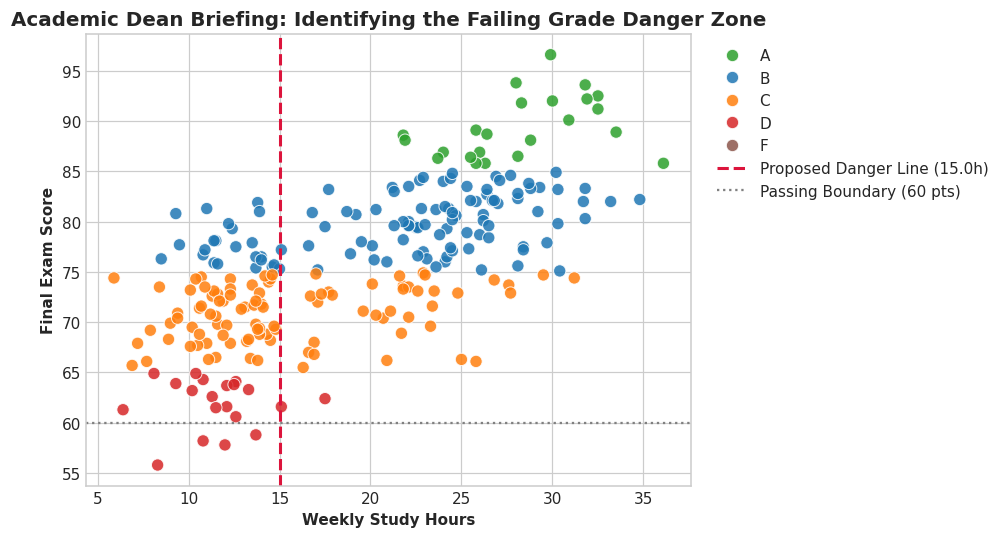

In [1]:
# =========================================================================
# MISSION 1 STARTER CODE (Customize thresholds, styling, or annotations)
# =========================================================================
fig, ax = plt.subplots(figsize=(9, 5))

# Scatter plot colored by grade category
sns.scatterplot(
    data=df_students,
    x='study_hours_weekly',
    y='final_score',
    hue='grade',
    hue_order=['A', 'B', 'C', 'D', 'F'],
    palette={'A': '#2ca02c', 'B': '#1f77b4', 'C': '#ff7f0e', 'D': '#d62728', 'F': '#8c564b'},
    s=65,
    alpha=0.85,
    ax=ax
)

# TODO: Group 1 - Adjust this vertical danger threshold and analyze what falls to the left!
danger_hours_threshold = 15.0
ax.axvline(danger_hours_threshold, color='crimson', linestyle='--', linewidth=2, label=f'Proposed Danger Line ({danger_hours_threshold}h)')
ax.axhline(60, color='gray', linestyle=':', label='Passing Boundary (60 pts)')

ax.set_title('Academic Dean Briefing: Identifying the Failing Grade Danger Zone', fontweight='bold', fontsize=13)
ax.set_xlabel('Weekly Study Hours', fontweight='semibold')
ax.set_ylabel('Final Exam Score', fontweight='semibold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

---
## 🧠 MISSION 2: The "Burnout & Mental Health" Taskforce
**Your Stakeholder**: The Director of Campus Counseling & Student Wellbeing.  
**The Problem**: The counseling center wants to schedule wellness workshops before students reach breaking points. Using `df_weekly`, identify the exact week when stress peaks. Does heavy studying cause stress, or does intense cramming trigger right before exams?

**Your Team's Questions to Answer in 60s**:
1. Which week experiences the sharpest surge in reported stress levels?
2. What happened to study hours immediately after Week 6 midterms? (Look at Week 7).
3. In which week must the university launch stress-management interventions?

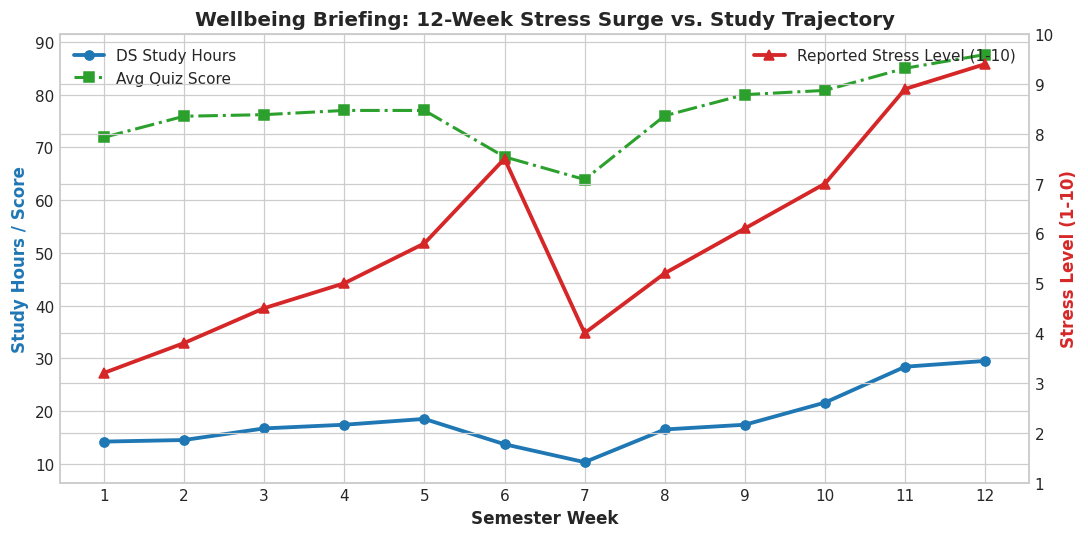

In [1]:
# =========================================================================
# MISSION 2 STARTER CODE (Customize shaded regions, twin axis, or lines)
# =========================================================================
fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary Axis: Study Hours & Quiz Scores
ax1.plot(df_weekly['week'], df_weekly['study_hours_datascience'], marker='o', color='#1f77b4', linewidth=2.5, label='DS Study Hours')
ax1.plot(df_weekly['week'], df_weekly['avg_quiz_score'], marker='s', color='#2ca02c', linewidth=2, linestyle='-.', label='Avg Quiz Score')
ax1.set_xlabel('Semester Week', fontweight='bold', fontsize=11)
ax1.set_ylabel('Study Hours / Score', color='#1f77b4', fontweight='bold', fontsize=11)
ax1.set_xticks(df_weekly['week'])

# Secondary Axis: Stress Level (1 to 10)
ax2 = ax1.twinx()
ax2.plot(df_weekly['week'], df_weekly['stress_level'], marker='^', color='#d62728', linewidth=2.5, label='Reported Stress Level (1-10)')
ax2.set_ylabel('Stress Level (1-10)', color='#d62728', fontweight='bold', fontsize=11)
ax2.set_ylim(1, 10)

# TODO: Group 2 - Add a shaded span or annotation to highlight the critical intervention window!
# ax1.axvspan(5.5, 7.5, color='gold', alpha=0.25, label='Crisis Window')

ax1.set_title('Wellbeing Briefing: 12-Week Stress Surge vs. Study Trajectory', fontweight='bold', fontsize=13)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## ⚖️ MISSION 3: The "Curriculum & Major Equity" Audit
**Your Stakeholder**: The Head of Engineering & Science Curriculum.  
**The Problem**: Mechanical and Electrical Engineering students claim that Computer Science and Data Science courses are graded much easier. Investigate whether differences in final exam scores reflect unfair grading or simply differences in weekly study hours.

**Your Team's Questions to Answer in 60s**:
1. Does Computer Science really achieve significantly higher scores than Mechanical Engineering?
2. When you compare study hours across majors, does the higher score make sense?
3. **Ethical Trap**: Did your chart start the Y-axis at 0? What happens if you truncate the axis to start at 70?

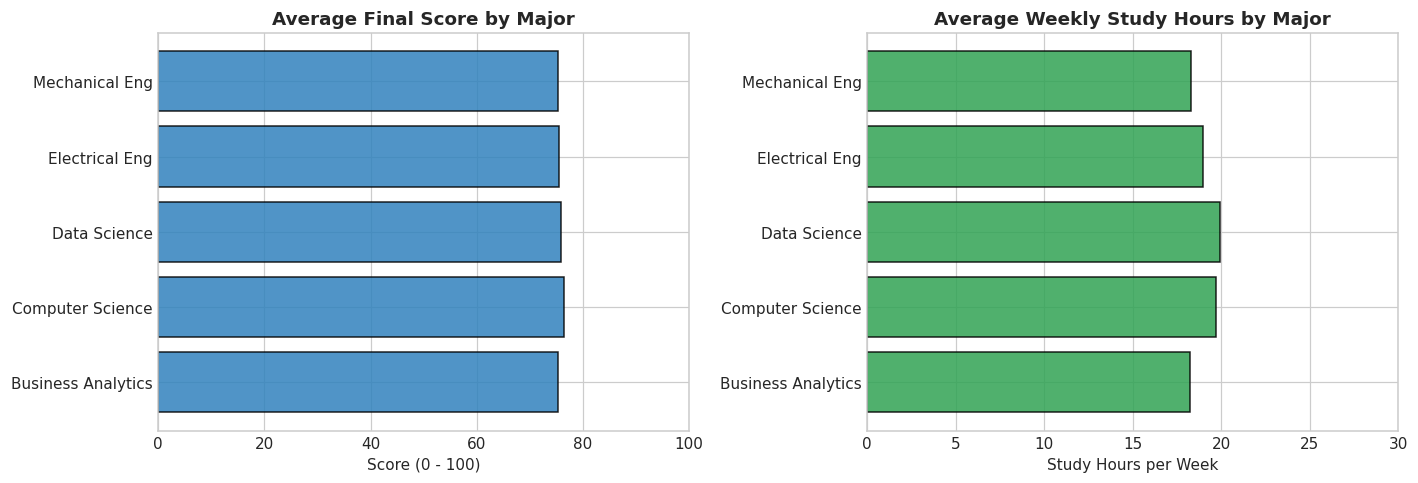

In [1]:
# =========================================================================
# MISSION 3 STARTER CODE (Compare scores and study hours across majors)
# =========================================================================
major_comparison = df_students.groupby('major').agg(
    avg_score=('final_score', 'mean'),
    avg_study_hours=('study_hours_weekly', 'mean'),
    count=('student_id', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 1. Average Final Score by Major (Horizontal Bar)
axes[0].barh(major_comparison['major'], major_comparison['avg_score'], color='#3182bd', edgecolor='black', alpha=0.85)
axes[0].set_title('Average Final Score by Major', fontweight='bold')
axes[0].set_xlabel('Score (0 - 100)')
axes[0].set_xlim(0, 100)  # Always start at 0!

# 2. Average Weekly Study Hours by Major
axes[1].barh(major_comparison['major'], major_comparison['avg_study_hours'], color='#31a354', edgecolor='black', alpha=0.85)
axes[1].set_title('Average Weekly Study Hours by Major', fontweight='bold')
axes[1].set_xlabel('Study Hours per Week')
axes[1].set_xlim(0, 30)

# TODO: Group 3 - Add text value labels inside or beside the bars!
plt.tight_layout()
plt.show()

---
## 🚌 MISSION 4: The "Commuter Reality Check" Taskforce
**Your Stakeholder**: The Director of Campus Housing & Commuter Student Services.  
**The Problem**: Commuter students claim long travel times ruin their academic success. What do students actually sacrifice when their commute is long: sleep, leisure, or self-study? Does long commute directly tank grades?

**Your Team's Questions to Answer in 60s**:
1. As `daily_commute_hrs` increases, which activity drops fastest: `daily_sleep_hrs` or `daily_study_hrs`?
2. How strong is the correlation between commute time and final exam score?
3. Defend why a **Stacked Bar Chart** or **Scatter Plot** is far superior to a 5-slice Pie Chart for this analysis.

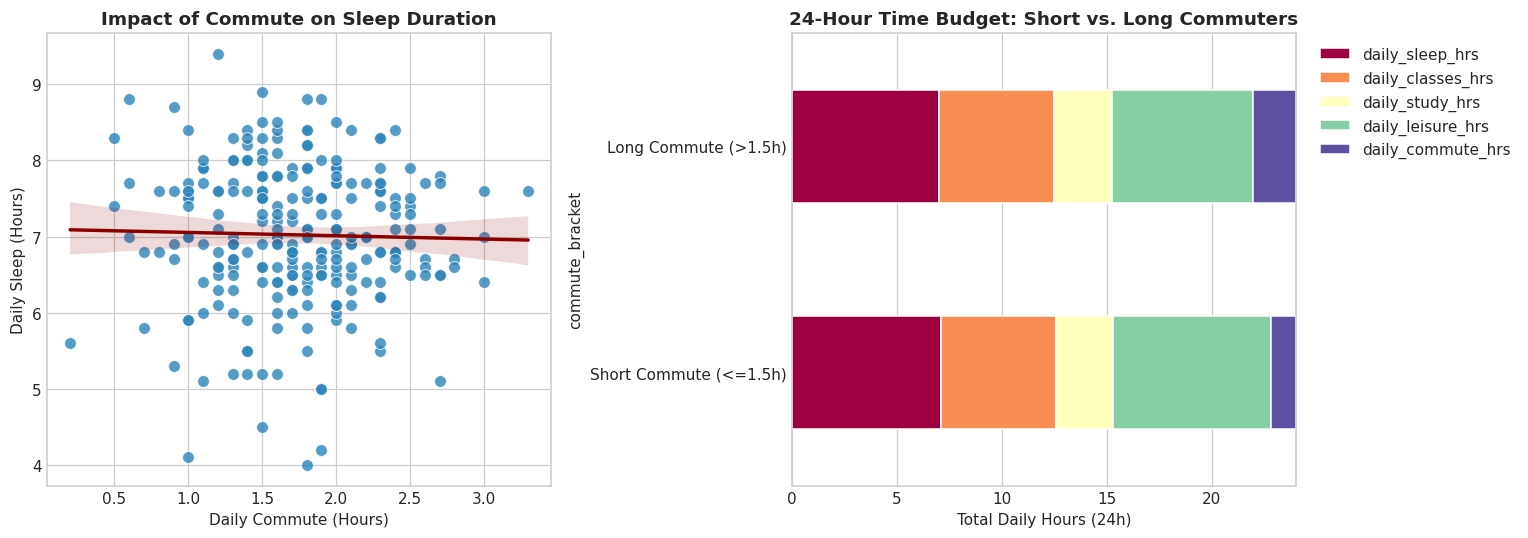

In [1]:
# =========================================================================
# MISSION 4 STARTER CODE (Explore commute impact on sleep and score)
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Commute vs Sleep with Trendline
sns.scatterplot(data=df_students, x='daily_commute_hrs', y='daily_sleep_hrs', color='#2b83ba', s=60, alpha=0.8, ax=axes[0])
sns.regplot(data=df_students, x='daily_commute_hrs', y='daily_sleep_hrs', scatter=False, color='darkred', ax=axes[0])
axes[0].set_title('Impact of Commute on Sleep Duration', fontweight='bold')
axes[0].set_xlabel('Daily Commute (Hours)')
axes[0].set_ylabel('Daily Sleep (Hours)')

# 2. Daily 24-Hour Time Allocation by Commute Bracket (Short vs Long Commute)
df_students['commute_bracket'] = pd.cut(df_students['daily_commute_hrs'], bins=[0, 1.5, 4.0], labels=['Short Commute (<=1.5h)', 'Long Commute (>1.5h)'])
bracket_time = df_students.groupby('commute_bracket', observed=False)[['daily_sleep_hrs', 'daily_classes_hrs', 'daily_study_hrs', 'daily_leisure_hrs', 'daily_commute_hrs']].mean()

bracket_time.plot(kind='barh', stacked=True, colormap='Spectral', edgecolor='white', ax=axes[1])
axes[1].set_title('24-Hour Time Budget: Short vs. Long Commuters', fontweight='bold')
axes[1].set_xlabel('Total Daily Hours (24h)')
axes[1].set_xlim(0, 24)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

---
## 🗺️ MISSION 5: The "Regional Talent & Admissions" Board
**Your Stakeholder**: The University Admissions & Scholarship Board.  
**The Problem**: The university wants to allocate regional diversity scholarships. Are students from distant states (`Delhi`, `Maharashtra`) performing as well as local students (`Karnataka`, `Kerala`)? Where should admissions focus recruitment?

**Your Team's Questions to Answer in 60s**:
1. Which state region has the highest average final score?
2. Which state region has the lowest student enrollment count (potential untapped talent)?
3. **Analytical Trap**: Why is it dangerous to compare states using only the average score without showing the student count ($n$)?

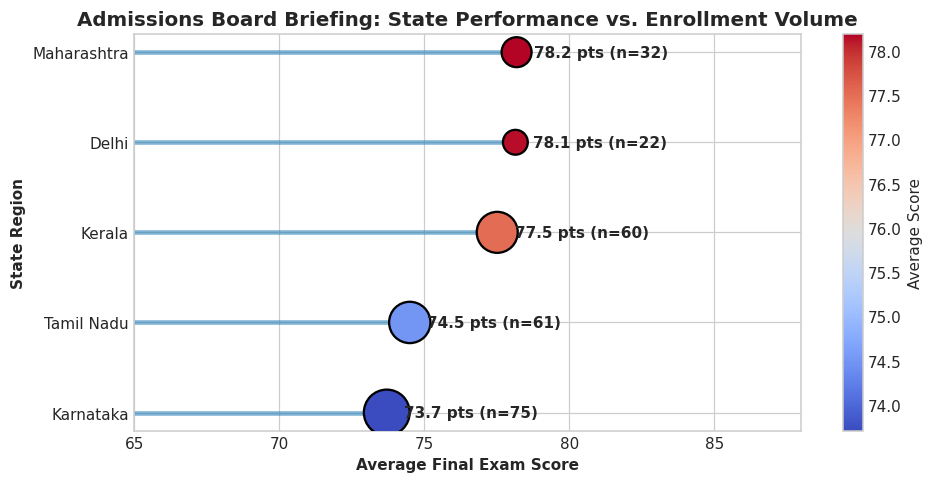

In [1]:
# =========================================================================
# MISSION 5 STARTER CODE (Lollipop / Bubble Chart showing score + sample size)
# =========================================================================
state_summary = df_students.groupby('state_region').agg(
    student_count=('student_id', 'count'),
    avg_score=('final_score', 'mean'),
    median_score=('final_score', 'median')
).reset_index().sort_values(by='avg_score', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))

# Horizontal lollipop stems
ax.hlines(y=state_summary['state_region'], xmin=65, xmax=state_summary['avg_score'], color='#2b83ba', linewidth=3, alpha=0.6)

# Bubble dots sized by student count
scatter = ax.scatter(
    state_summary['avg_score'], 
    state_summary['state_region'], 
    s=state_summary['student_count'] * 12,  # Bubble size = enrollment volume
    c=state_summary['avg_score'], 
    cmap='coolwarm', 
    edgecolors='black',
    linewidth=1.5,
    zorder=3
)

# Add data label with both mean score and sample size (n)
for _, row in state_summary.iterrows():
    ax.text(row['avg_score'] + 0.6, row['state_region'], f"{row['avg_score']:.1f} pts (n={row['student_count']})", va='center', fontweight='bold')

ax.set_xlim(65, 88)
ax.set_title('Admissions Board Briefing: State Performance vs. Enrollment Volume', fontweight='bold', fontsize=13)
ax.set_xlabel('Average Final Exam Score', fontweight='semibold')
ax.set_ylabel('State Region', fontweight='semibold')
plt.colorbar(scatter, label='Average Score')

plt.tight_layout()
plt.show()